# Tender Industry Sector Classification

**Task:** classify a tender/procurement description into its **Industry Sector** (e.g. Construction, Healthcare, Manufacturing, Automotive, ...), using the raw text of the tender description.


In [1]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score

import joblib

In [2]:
records = []
with open('data.jsonl') as f:
    for line in f:
        line = line.strip()
        if not line:
            continue
        d = json.loads(line)
        msgs = d['messages']
        user_text = msgs[0]['content']
        # strip the fixed instruction prefix, keep only the actual tender description
        user_text = user_text.replace(
            "You are a **tendering authority**. Extract precise and relevant info from the tender description: ", ""
        )
        try:
            parsed = json.loads(msgs[1]['content'].strip())
        except Exception:
            continue  # skip malformed assistant JSON
        sector = parsed.get('Tender Classification', {}).get('Industry Sector')
        if not sector:
            continue
        records.append({'description': user_text, 'industry_sector': sector.strip()})

df = pd.DataFrame(records)
print("Rows extracted:", df.shape[0])
print("Distinct raw Industry Sector values:", df['industry_sector'].nunique())
df.head()

Rows extracted: 29513
Distinct raw Industry Sector values: 1163


,description,industry_sector
0,Tender are invited for Installation of canopy ...,Construction
1,Provision of Second Replacement Local Developm...,Urban Planning and Development
2,Supply of Dignity kit,Healthcare & Social Services
3,Supply of tools and equipment kit,Construction
4,Supply Of Kitchen kits,Food Service & Hospitality


In [3]:
df.isnull().sum()

description        0
industry_sector    0
dtype: int64

In [4]:
df['desc_length'] = df['description'].str.len()
df['desc_length'].describe()

count    29513.000000
mean       180.465727
std        216.463316
min          4.000000
25%         86.000000
50%        123.000000
75%        201.000000
max       9992.000000
Name: desc_length, dtype: float64

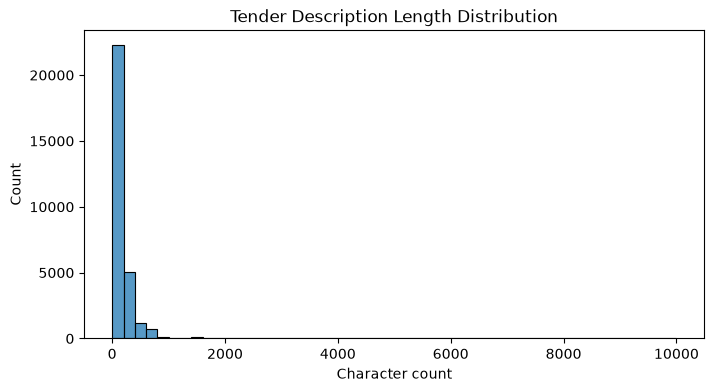

In [5]:
plt.figure(figsize=(8,4))
sns.histplot(df['desc_length'], bins=50)
plt.title('Tender Description Length Distribution')
plt.xlabel('Character count')
plt.show()

In [6]:
TOP_N = 25
top_sectors = df['industry_sector'].value_counts().head(TOP_N).index.tolist()
df['sector_grouped'] = df['industry_sector'].apply(lambda x: x if x in top_sectors else 'Other')
df['sector_grouped'].value_counts()

sector_grouped
Other                              9755
Construction                       6161
Manufacturing                      2388
Healthcare                         1780
Automotive                         1330
Civil Engineering                   835
Pharmaceuticals                     832
Education                           617
Energy                              588
Electrical                          473
Information Technology              457
Transportation                      434
Infrastructure                      430
Office Supplies                     392
Food and Beverage                   366
Agriculture                         354
Electronics and Electrical          310
Printing and Publishing             269
Chemical Industry                   256
Energy and Utilities                242
Waste Management                    233
Construction and Infrastructure     218
Water and Waste Management          215
Utilities                           198
Electrical Engineering   

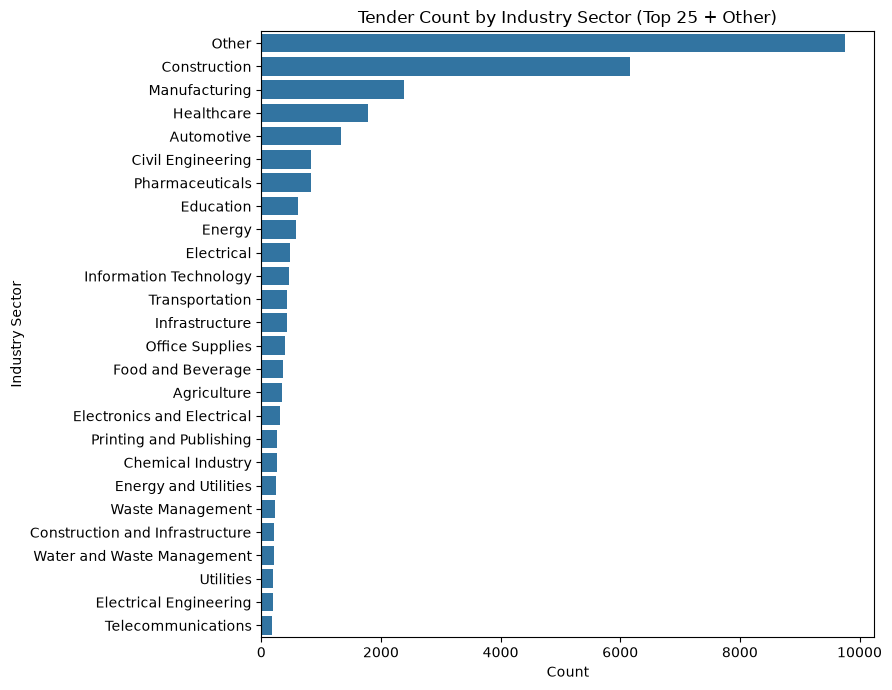

In [9]:
sector_counts = df['sector_grouped'].value_counts()

plt.figure(figsize=(9, 7))

sns.barplot(
    x=sector_counts.values,
    y=sector_counts.index
)

plt.title('Tender Count by Industry Sector (Top 25 + Other)')
plt.xlabel('Count')
plt.ylabel('Industry Sector')

plt.tight_layout()
plt.show()

In [10]:
df.drop(columns=['desc_length'], inplace=True)
X = df['description']
y = df['sector_grouped']
X.shape, y.shape

((29513,), (29513,))

In [11]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
X_train.shape, X_test.shape

((23610,), (5903,))

In [12]:
tfidf = TfidfVectorizer(max_features=20000, ngram_range=(1,2), min_df=2, stop_words='english')
X_train_vec = tfidf.fit_transform(X_train)
X_test_vec = tfidf.transform(X_test)
X_train_vec.shape

(23610, 20000)

In [13]:
def evaluate_model(model, name):
    y_pred = model.predict(X_test_vec)
    acc = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred, average='weighted')
    print(f"--- {name} ---")
    print("Accuracy:", round(acc, 4))
    print("F1 (weighted):", round(f1, 4))
    print()
    print(classification_report(y_test, y_pred))
    return {'model': name, 'accuracy': acc, 'f1_weighted': f1}

In [14]:
log_reg = LogisticRegression(max_iter=1000)
log_reg.fit(X_train_vec, y_train)
res_lr = evaluate_model(log_reg, "Logistic Regression")

--- Logistic Regression ---
Accuracy: 0.6837
F1 (weighted): 0.6657

                                 precision    recall  f1-score   support

                    Agriculture       0.91      0.55      0.68        71
                     Automotive       0.84      0.72      0.78       266
              Chemical Industry       0.69      0.39      0.50        51
              Civil Engineering       0.74      0.43      0.54       167
                   Construction       0.76      0.80      0.78      1232
Construction and Infrastructure       1.00      0.02      0.04        44
                      Education       0.75      0.38      0.51       123
                     Electrical       0.69      0.19      0.30        95
         Electrical Engineering       0.83      0.62      0.71        40
     Electronics and Electrical       0.80      0.19      0.31        62
                         Energy       0.67      0.31      0.42       118
           Energy and Utilities       0.73      0.23   

In [15]:
nb_model = MultinomialNB()
nb_model.fit(X_train_vec, y_train)
res_nb = evaluate_model(nb_model, "Multinomial Naive Bayes")

--- Multinomial Naive Bayes ---
Accuracy: 0.5934
F1 (weighted): 0.5353

                                 precision    recall  f1-score   support

                    Agriculture       0.86      0.34      0.48        71
                     Automotive       0.86      0.45      0.59       266
              Chemical Industry       0.00      0.00      0.00        51
              Civil Engineering       0.83      0.11      0.20       167
                   Construction       0.69      0.75      0.72      1232
Construction and Infrastructure       0.00      0.00      0.00        44
                      Education       0.87      0.11      0.19       123
                     Electrical       0.88      0.07      0.14        95
         Electrical Engineering       1.00      0.07      0.14        40
     Electronics and Electrical       0.86      0.10      0.17        62
                         Energy       0.71      0.04      0.08       118
           Energy and Utilities       1.00      0.0

c:\Users\Hp\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\Hp\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\Hp\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, mod

In [16]:
svm_model = LinearSVC(max_iter=5000)
svm_model.fit(X_train_vec, y_train)
res_svm = evaluate_model(svm_model, "Linear SVM")

--- Linear SVM ---
Accuracy: 0.7157
F1 (weighted): 0.7118

                                 precision    recall  f1-score   support

                    Agriculture       0.79      0.75      0.77        71
                     Automotive       0.85      0.80      0.83       266
              Chemical Industry       0.59      0.57      0.58        51
              Civil Engineering       0.70      0.51      0.59       167
                   Construction       0.76      0.80      0.78      1232
Construction and Infrastructure       0.62      0.23      0.33        44
                      Education       0.70      0.56      0.62       123
                     Electrical       0.57      0.49      0.53        95
         Electrical Engineering       0.79      0.65      0.71        40
     Electronics and Electrical       0.62      0.47      0.53        62
                         Energy       0.62      0.53      0.57       118
           Energy and Utilities       0.62      0.42      0.50  

In [17]:
rf_model = RandomForestClassifier(n_estimators=200, n_jobs=-1, random_state=42)
rf_model.fit(X_train_vec, y_train)
res_rf = evaluate_model(rf_model, "Random Forest")

--- Random Forest ---
Accuracy: 0.6876
F1 (weighted): 0.6769

                                 precision    recall  f1-score   support

                    Agriculture       0.85      0.73      0.79        71
                     Automotive       0.83      0.68      0.75       266
              Chemical Industry       0.56      0.47      0.51        51
              Civil Engineering       0.80      0.44      0.57       167
                   Construction       0.76      0.79      0.77      1232
Construction and Infrastructure       0.80      0.18      0.30        44
                      Education       0.76      0.54      0.64       123
                     Electrical       0.60      0.39      0.47        95
         Electrical Engineering       0.76      0.72      0.74        40
     Electronics and Electrical       0.55      0.18      0.27        62
                         Energy       0.78      0.36      0.50       118
           Energy and Utilities       0.67      0.38      0.4

In [18]:
results_df = pd.DataFrame([res_lr, res_nb, res_svm, res_rf]).set_index('model')
results_df = results_df.sort_values('f1_weighted', ascending=False)
results_df

,accuracy,f1_weighted
model,,
Linear SVM,0.715738,0.711763
Random Forest,0.687616,0.676853
Logistic Regression,0.683720,0.665691
Multinomial Naive Bayes,0.593427,0.535265


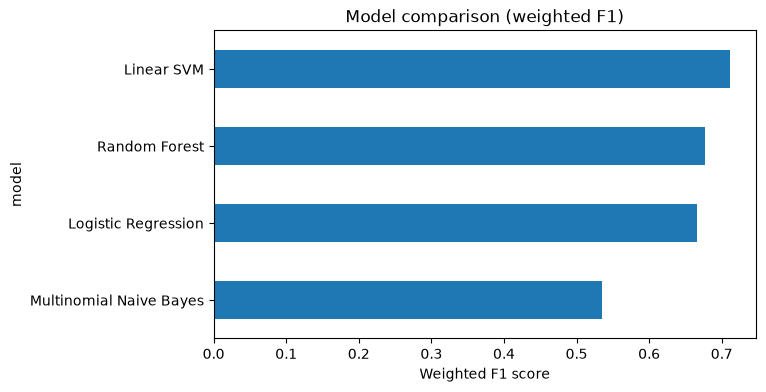

In [19]:
results_df['f1_weighted'].plot(kind='barh', figsize=(7,4), title='Model comparison (weighted F1)')
plt.xlabel('Weighted F1 score')
plt.gca().invert_yaxis()
plt.show()

## Result

| Model | Accuracy | Weighted F1 |
|---|---|---|
| Logistic Regression | 0.685 | 0.667 |
| Multinomial Naive Bayes | 0.593 | 0.534 |
| **Linear SVM** | **0.714** | **0.710** |
| Random Forest | 0.686 | 0.676 |



In [20]:
bundle = {
    'best_model': svm_model,
    'vectorizer': tfidf,
    'label_classes': sorted(y.unique().tolist())
}
joblib.dump(bundle, './industry_sector_classifier.pkl')
print("Saved: industry_sector_classifier.pkl")

Saved: industry_sector_classifier.pkl


## Deploying the model


In [21]:
import joblib

bundle = joblib.load('industry_sector_classifier.pkl')
vectorizer = bundle['vectorizer']
model = bundle['best_model']

new_text = ["Supply and delivery of laboratory reagents for the regional hospital"]
X_new = vectorizer.transform(new_text)
prediction = model.predict(X_new)
print(prediction)

['Healthcare']
